In [2]:
import pandas as pd
from pathlib import Path

BASE_DIR = Path("")

dfs = []

for model_dir in BASE_DIR.iterdir():
    if not model_dir.is_dir():
        continue

    csvs = list(model_dir.glob("*exp2b*.csv"))
    if not csvs:
        continue

    df = pd.read_csv(csvs[0])
    df["model"] = model_dir.name
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)

# 统一数值格式（已经 round 过也没问题）
for c in ["spearman_r", "spearman_p", "pearson_r", "pearson_p"]:
    if c in df_all.columns:
        df_all[c] = df_all[c].round(4)


In [3]:
df_all["alignment_strength"] = df_all["spearman_r"].abs()
trait_best = (
    df_all
    .sort_values("alignment_strength", ascending=False)
    .groupby(["model", "trait"])
    .first()
    .reset_index()
)

print(trait_best)


       model                   trait              metric  n  spearman_r  \
0   deepseek          Aggressiveness          raise_rate  5      0.9000   
1   deepseek          BluffFrequency  bluff_success_rate  5     -1.0000   
2   deepseek  CallingStationTendency   aggression_factor  5     -0.8000   
3   deepseek           RiskTolerance           fold_rate  5     -0.9000   
4   deepseek      ShowdownPropensity           fold_rate  5      0.8000   
5     gemini          Aggressiveness           fold_rate  5     -0.9000   
6     gemini          BluffFrequency          raise_rate  5      0.8000   
7     gemini  CallingStationTendency  call_to_fold_ratio  5      0.8000   
8     gemini           RiskTolerance           fold_rate  5     -0.8000   
9     gemini      ShowdownPropensity           fold_rate  5     -0.9000   
10       gpt          Aggressiveness          raise_rate  5      0.7000   
11       gpt          BluffFrequency  bluff_attempt_rate  5      0.9000   
12       gpt  CallingStat

In [4]:
trait_summary = (
    df_all
    .groupby("trait")["alignment_strength"]
    .agg(["mean", "std", "count"])
    .reset_index()
    .sort_values("mean", ascending=False)
)

print(trait_summary)


                    trait      mean       std  count
1          BluffFrequency  0.798056  0.179994     18
0          Aggressiveness  0.745833  0.144400     24
3           RiskTolerance  0.670833  0.240433     24
2  CallingStationTendency  0.508333  0.278063     24
4      ShowdownPropensity  0.473813  0.297919     15


In [5]:
model_summary = (
    df_all
    .groupby("model")["alignment_strength"]
    .mean()
    .reset_index()
    .sort_values("alignment_strength", ascending=False)
)

print(model_summary)


      model  alignment_strength
0  deepseek            0.719644
4     llama            0.700000
3      grok            0.650882
1    gemini            0.641867
5      qwen            0.641176
2       gpt            0.516667


In [6]:
main_table = trait_best[[
    "model", "trait", "metric",
    "spearman_r", "spearman_p"
]].sort_values(["trait", "model"])

main_table.to_csv("exp2b_main_comparison_table.csv", index=False)


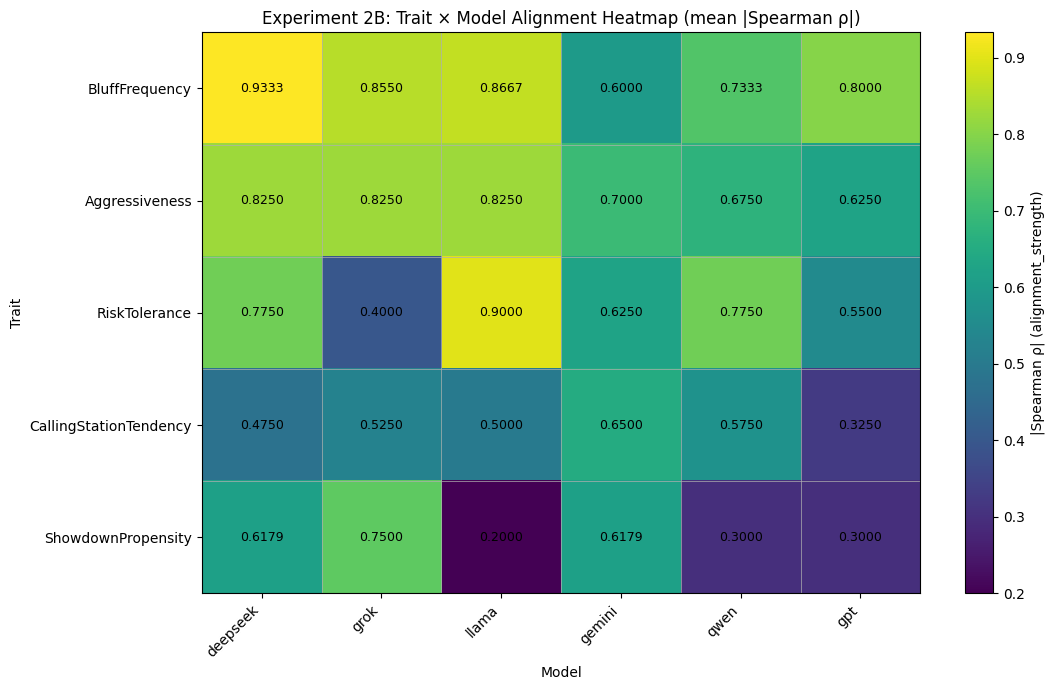

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# df_all: columns should include
# ['model', 'trait', 'spearman_r'] or already ['alignment_strength']
# -----------------------------
# 如果 df_all 尚未定义，就先读你的总表（按需改路径）
# df_all = pd.read_csv("exp2b_all_models_merged.csv")

# 1) 统一对齐强度：abs(spearman_r)
if "alignment_strength" not in df_all.columns:
    if "spearman_r" not in df_all.columns:
        raise ValueError("df_all needs 'alignment_strength' or 'spearman_r'.")
    df_all["alignment_strength"] = df_all["spearman_r"].abs()

# 2) pivot：Trait × Model（每个格子取 mean，你也可以改成 max）
heat = df_all.pivot_table(
    index="trait",
    columns="model",
    values="alignment_strength",
    aggfunc="mean"
)

# 3) 可选：排序（按 trait 的平均对齐强度降序；model 按整体均值降序）
trait_order = heat.mean(axis=1).sort_values(ascending=False).index
model_order = heat.mean(axis=0).sort_values(ascending=False).index
heat = heat.loc[trait_order, model_order]

# 4) 转成 numpy，处理 NaN（mask 掉）
data = heat.to_numpy(dtype=float)
masked = np.ma.masked_invalid(data)

# 5) 画 heatmap
plt.figure(figsize=(1.2 * len(heat.columns) + 4, 0.8 * len(heat.index) + 3))
ax = plt.gca()

im = ax.imshow(masked, aspect="auto")  # 不指定 cmap，使用 matplotlib 默认
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("|Spearman ρ| (alignment_strength)")

# 6) 坐标轴标签
ax.set_xticks(np.arange(len(heat.columns)))
ax.set_yticks(np.arange(len(heat.index)))
ax.set_xticklabels(heat.columns, rotation=45, ha="right")
ax.set_yticklabels(heat.index)

ax.set_xlabel("Model")
ax.set_ylabel("Trait")
ax.set_title("Experiment 2B: Trait × Model Alignment Heatmap (mean |Spearman ρ|)")

# 7) 在格子里标注数值（四位小数），NaN 跳过
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        val = data[i, j]
        if np.isfinite(val):
            ax.text(j, i, f"{val:.4f}", ha="center", va="center", fontsize=9)

# 8) 网格线（可选，让表格更像论文图）
ax.set_xticks(np.arange(-0.5, len(heat.columns), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(heat.index), 1), minor=True)
ax.grid(which="minor", linestyle="-", linewidth=0.5)
ax.tick_params(which="minor", bottom=False, left=False)

plt.tight_layout()
plt.savefig("exp2b_trait_model_heatmap.pdf", dpi=300)
plt.show()


实验 2B：讨论 — 配置文件与行为统计之间的对齐

实验 2B 探讨了由大语言模型（LLM）推断的对手配置文件是否基于客观的扑克行为统计数据，超越相对排名（实验 2A），以评估绝对语义对齐。跨模型与特质，结果揭示出一贯但受特质影响的 grounding 模式，支持对手配置文件捕捉到有意义的行为倾向，而非任意标签的假设。

特质依赖的对齐强度
在配置文件维度之间，对齐强度呈现出明确的层级结构。BluffFrequency（虚张声势频率）和 Aggressiveness（攻击性）展现出最强且最稳定的对齐，平均绝对斯皮尔曼相关系数约为 0.80 与 0.75，且在模型之间方差相对较小。这些特质与有意的、行动层面的决策直接相关——例如提高筹码频率或进行诈唬尝试——在 prompting 方案中被明确表示，并且在对局统计中容易观察到。这些对齐的鲁棒性表明，LLMs 能够将风格意图特质可靠地 grounding 于具体的下注行为。

相较之下，RiskTolerance（风险容忍度）与对齐呈中等强度但方差较高，反映其更抽象的性质。不同模型通过语义上兼容但不同的行为代理来体现风险，如增加参与度（类似 VPIP 的测量）、减少弃牌，或提高加注频率等。这种变异性并不表示失败；相反地，它强调风险容忍度是一个元特质，具有多种有效的行为体现，LLMs 会根据内部表示选择不同的代理。

CallingStationTendency（跟注场景倾向）显示出较弱的平均对齐和更高的方差，尽管在语义上定义良好。深入观察发现，模型普遍将该特质与被动性联系在一起——最常通过降低攻击性因子或提高跟注-弃牌比来体现——但在强调的具体统计量上存在差异。这一发现表明在概念层面存在语义一致性，但在操作化上存在异质性，暗示被动倾向是通过间接方式捕捉的，而不是通过单一的规范性指标。

最后，ShowdownPropensity（摊牌倾向）成为对齐度最低的特质，平均相关最低且方差最高。之所以如此，是因为摊牌是稀疏的、受结果影响的事件，受多种相互作用因素影响，包括对手行为和牌面分布。值得注意的是，模型倾向于将该特质 grounding 在与坚持相关的行为上（例如更多跟注或更少弃牌），而不是直接的摊牌频率，反映出对摊牌所需但并非充分条件的依赖。这揭示了在有限数据情形下，基于结果的统计的固有限制。

模型层面的差异与稳定性
在模型层面，所有评估的 LLMs 都表现出 inferred profiles 与行为统计之间的非平凡对齐，表明对手建模能力并非限于单一架构。然而，稳定性和极性方面仍存在差异。某些模型在小样本规模下因极端相关性而带来更高的平均对齐强度，而另一些模型则在各特质上表现出更均衡、保守的对齐。这些模式提示，尽管总体的画像能力是共享的，但模型在将特质估计极化到何种程度以及优先考虑哪些行为线索方面有所不同。

意图层级与结果层级的语义
在所有特质和模型中，一个统一的洞见是：意图层级的行为对齐强于结果层级的统计对齐。描述策略意图的特质——如攻击性或诈唬频率——始终映射到行动频率（加注、跟注、尝试诈唬），而与下游结果相关的特质——如摊牌或成功率——的 grounding 衰弱且不稳定。这一区分意味着基于 LLM 的对手配置文件主要编码行为风格与决策倾向，而非实现的收益或罕见的终局事件。

局限性与含义
在解读这些发现时应考虑若干局限。每个模型的对手数量较少，统计能力受限，因此更倾向于使用基于排名的相关性和聚合趋势，而非严格的假设检验。此外，若干行为代理是可用日志所必需的近似估计，替代指标也可能进一步完善对齐评估。尽管存在这些约束，趋势方向的一致性和跨特质的语义一致性为证据，表明 LLM 生成的对手配置文件在行为上是 grounding 的。

总体而言，实验 2B 通过展示 LLM 不仅能对对手进行有意义的排序，还能将配置维度 anch or 于客观的对局统计数据，补充了实验 2A 中基于排名的分析。综合而言，这些结果支持这样的观点：在 LLM 驱动的代理中，对手画像是一种结构化、可解释的内部状态，与可观测的行为保持一致，为后续实验中探讨的因果干预奠定基础。

Experiment 2B: Discussion — Alignment Between Profiles and Behavioral Statistics

Experiment 2B investigated whether LLM-inferred opponent profiles are grounded in objective poker behavior statistics, moving beyond relative ranking (Experiment 2A) to assess absolute semantic alignment. Across models and traits, the results reveal a consistent but trait-dependent pattern of grounding, supporting the hypothesis that opponent profiles capture meaningful behavioral tendencies rather than arbitrary labels.

Trait-Dependent Grounding Strength

A clear hierarchy emerges in terms of alignment strength across profile dimensions. BluffFrequency and Aggressiveness exhibit the strongest and most stable alignment, with average absolute Spearman correlations of approximately 0.80 and 0.75, respectively, and relatively low variance across models. These traits are directly associated with intentional, action-level decisions—such as raising frequency or bluff attempts—which are both explicitly represented in the prompting scheme and readily observable in gameplay statistics. The robustness of these alignments suggests that LLMs reliably ground stylistic intent traits in concrete betting behaviors.

In contrast, RiskTolerance demonstrates moderate alignment with higher variance, reflecting its more abstract nature. Different models operationalize risk through semantically compatible but distinct behavioral proxies, such as increased participation (VPIP-like measures), reduced folding, or higher raising frequency. This variability does not indicate failure; rather, it highlights that RiskTolerance is a meta-trait with multiple valid behavioral instantiations, and LLMs select different proxies depending on their internal representations.

CallingStationTendency shows weaker average alignment and higher variance, despite being semantically well-defined. Closer inspection reveals that models consistently associate this trait with passivity—most commonly through reduced aggression factors or elevated call-to-fold ratios—but differ in which specific statistic they emphasize. This finding indicates semantic consistency at a conceptual level but heterogeneity in operationalization, suggesting that passive tendencies are captured indirectly rather than via a single canonical metric.

Finally, ShowdownPropensity emerges as the least aligned trait, with the lowest mean correlation and highest variance. This outcome is expected given that showdowns are sparse, outcome-dependent events influenced by multiple interacting factors, including opponent actions and card distributions. Notably, models tend to ground this trait in persistence-related behaviors (e.g., calling more or folding less) rather than direct showdown frequency, reflecting reliance on necessary but not sufficient conditions for reaching showdown. This highlights an inherent limitation of outcome-based statistics under limited data regimes.

Model-Level Differences and Stability

At the model level, all evaluated LLMs exhibit non-trivial alignment between inferred profiles and behavioral statistics, indicating that opponent modeling capabilities are not confined to a single architecture. Differences nevertheless arise in stability and extremity. Some models achieve higher average alignment strength driven partly by extreme correlations under small sample sizes, whereas others demonstrate more balanced, conservative alignment across traits. These patterns suggest that while overall profiling competence is shared, models differ in how strongly they polarize trait estimates and which behavioral cues they prioritize.

Intent-Level vs. Outcome-Level Semantics

A unifying insight across traits and models is that intent-level behaviors align more strongly than outcome-level statistics. Traits describing strategic intent—such as aggressiveness or bluffing frequency—consistently map to action frequencies (raising, calling, attempting bluffs), whereas traits tied to downstream outcomes—such as showdowns or success rates—show weaker and less stable grounding. This distinction implies that LLM-based opponent profiles primarily encode behavioral style and decision tendencies rather than realized payoffs or rare terminal events.

Limitations and Implications

These findings should be interpreted in light of several limitations. The number of opponents per model is small, constraining statistical power and motivating the use of rank-based correlations and aggregate trends rather than strict hypothesis testing. Additionally, several behavioral proxies are approximations necessitated by available logs, and alternative metrics may further refine alignment assessments. Despite these constraints, the consistency of directional trends and semantic coherence across traits provide strong evidence that LLM-generated opponent profiles are behaviorally grounded.

Overall, Experiment 2B complements the ranking-based analysis in Experiment 2A by demonstrating that LLMs not only order opponents meaningfully but also anchor profile dimensions in objective gameplay statistics. Together, these results support the view that opponent profiling in LLM-driven agents represents a structured, interpretable internal state aligned with observable behavior, laying the groundwork for causal interventions explored in subsequent experiments.